In [111]:
import operator
from langgraph.graph import StateGraph,START,END
from typing import TypedDict, Any, Annotated, Dict, Literal
from langchain_groq import ChatGroq
from dotenv import load_dotenv
import os
from pydantic import BaseModel, Field
from langchain_core.messages import HumanMessage,AIMessage,SystemMessage

In [112]:
load_dotenv()
model = ChatGroq(model="llama-3.3-70b-versatile", 
                 api_key=os.getenv("API_KEY"),
                 temperature=0.1)

In [113]:
class TweetEvaluation(BaseModel):
    evaluation: Literal["approved", "needs_improvement"] = Field(..., description="Final evaluation result.")
    feedback: str = Field(..., description="feedback for the tweet.")

In [114]:
tweet_structured_output=model.with_structured_output(TweetEvaluation)

In [115]:
class TweetState(TypedDict):
    topic: str
    tweet: str
    evaluation: Literal["approved","modify"]
    feedback: str
    iteration_count: int
    max_iterations: int

In [116]:
def generate_tweet(state: TweetState):
      messages = [
        SystemMessage(content="You are a funny and clever Twitter/X influencer."),
        HumanMessage(content=f"""
            Write a short, original, and hilarious tweet on the topic: "{state['topic']}".

            Rules:
            - Do NOT use question-answer format.
            - Max 280 characters.
            - Use observational humor, irony, sarcasm, or cultural references.
            - Think in meme logic, punchlines, or relatable takes.
            - Use simple, day to day english
            """)
            ]
      response=model.invoke(messages).content
      return {"tweet":response}
    

In [117]:
def evaluate_tweet(state: TweetState):
      messages = [
      SystemMessage(content="You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor, originality, virality, and tweet format."),
      HumanMessage(content=f"""
      Evaluate the following tweet:

      Tweet: "{state['tweet']}"

      Use the criteria below to evaluate the tweet:

      1. Originality - Is this fresh, or have you seen it a hundred times before?  
      2. Humor - Did it genuinely make you smile, laugh, or chuckle?  
      3. Punchiness - Is it short, sharp, and scroll-stopping?  
      4. Virality Potential - Would people retweet or share it?  
      5. Format - Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?

      Auto-reject if:
      - It's written in question-answer format (e.g., "Why did..." or "What happens when...")
      - It exceeds 280 characters
      - It reads like a traditional setup-punchline joke
      - Dont end with generic, throwaway, or deflating lines that weaken the humor (e.g., “Masterpieces of the auntie-uncle universe” or vague summaries)

      ### Respond ONLY in structured format:
      - evaluation: "approved" or "needs_improvement"  
      - feedback: One paragraph explaining the strengths and weaknesses 
      """)
      ]
      
      response=tweet_structured_output.invoke(messages)
      return {"evaluation":response.evaluation,"feedback":response.feedback}
      
    

In [118]:
def optimise_tweet(state: TweetState):
    messages = [
        SystemMessage(content="You punch up tweets for virality and humor based on given feedback."),
        HumanMessage(content=f"""
        Improve the tweet based on this feedback:
        "{state['feedback']}"

        Topic: "{state['topic']}"
        Original Tweet:
        {state['tweet']}

        Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters.
        """)
    ]
    
    response=model.invoke(messages).content
    iteration=state['iteration_count']+1
    
    return {"response":response,"iteration_count":iteration}

In [119]:
def tweet_improvement_condition(state: TweetState):
    if state['evaluation'] == "approved" or state['iteration'] >= state['max_iteration']:
        return "approved"
    else:
        return "modify"

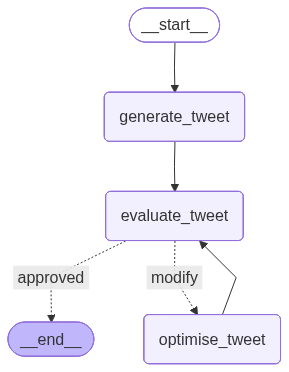

In [120]:
graph=StateGraph(TweetState)

graph.add_node("generate_tweet",generate_tweet)
graph.add_node("evaluate_tweet",evaluate_tweet)
graph.add_node("optimise_tweet",optimise_tweet)

graph.add_edge(START,"generate_tweet")
graph.add_edge("generate_tweet","evaluate_tweet")
graph.add_conditional_edges("evaluate_tweet",tweet_improvement_condition,{
    "approved": END,
    "modify": "optimise_tweet"
})

graph.add_edge("optimise_tweet","evaluate_tweet")
workflow=graph.compile()
workflow


In [121]:
initial_state={
    "topic":"upsc",
    "iteration_count": 1,
    "max_iterations": 3
}

In [122]:
result=workflow.invoke(initial_state)

In [123]:
result

{'topic': 'upsc',
 'tweet': '"UPSC aspirants be like: I\'ll study for 5 yrs, clear the exam, become an IAS officer and finally get the power to say \'file pe mat chhodo\' to someone else" #UPSC',
 'evaluation': 'approved',
 'feedback': "This tweet is a great example of a well-crafted joke that effectively uses relatable humor to poke fun at the struggles of UPSC aspirants. The originality of the tweet lies in its clever play on the phrase 'file pe mat chhodo,' which is a common phrase used in Indian bureaucracy. The humor is spot on, as it exaggerates the aspirations of UPSC candidates in a lighthearted way. The tweet is also punchy, concise, and scroll-stopping, making it likely to go viral. The format is well-executed, with a clear and concise message that stays within the 280-character limit. Overall, this tweet has a high virality potential and effectively uses humor to connect with its audience.",
 'iteration_count': 1,
 'max_iterations': 3}